## Setup 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.animation import FuncAnimation, PillowWriter


student_name = "Raym Eamon Geromo"
student_id = "20250082" 

# Load the cleaned dataset
df = pd.read_csv("spotify_top_1000_tracks.csv", encoding="utf-8")
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['decade'] = (df['release_year'] // 10) * 10
df['duration_min'] = df['duration_ms'] / 60000 if 'duration_ms' in df.columns else df['duration_min']

# Calculate personalized colors 
id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

print(f"Colors generated for {student_name}: {color1} and {color2}")

Colors generated for Raym Eamon Geromo: #3ef69a and #a4e248


In [2]:
pip install seaborn matplotlib pandas numpy lxml requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. 

In [5]:
print(f"Student: {student_name} | ID: {student_id}")
print(f"Color 1: {color1} | Color 2: {color2}")

Student: Raym Eamon Geromo | ID: 20250082
Color 1: #3ef69a | Color 2: #a4e248


## 1. 

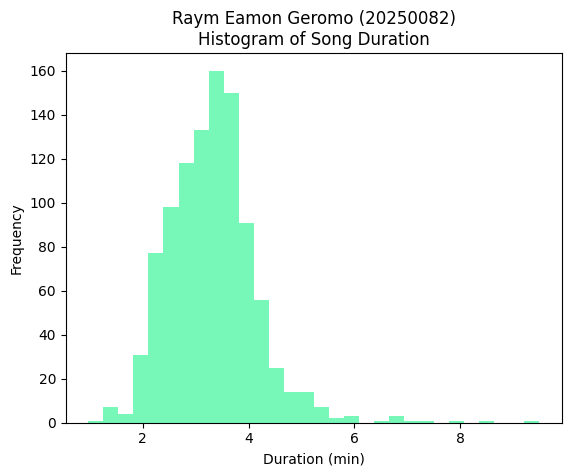

In [6]:
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

## 2. 

C:\Users\farah\AppData\Local\Temp\ipykernel_25552\3449483470.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


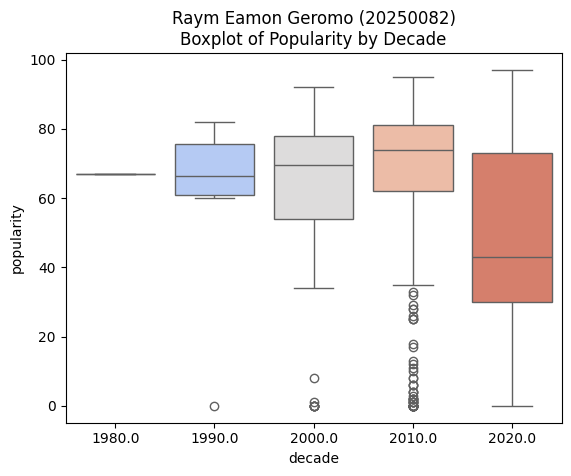

In [7]:
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()

## 3. 

C:\Users\farah\AppData\Local\Temp\ipykernel_25552\2261941100.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')


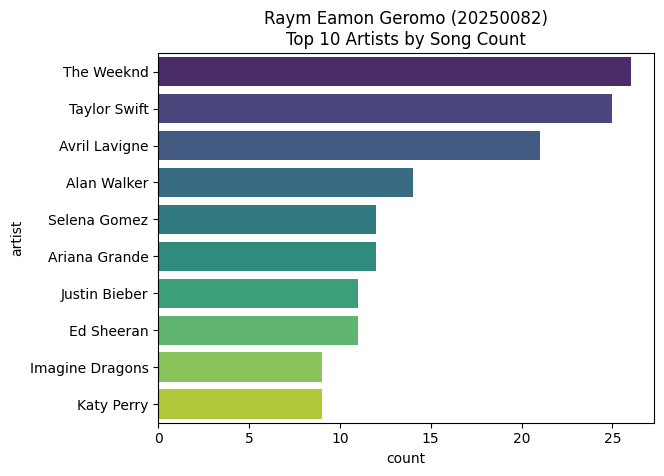

In [8]:
sns.countplot(y='artist', data=df, order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

## 4. 

C:\Users\farah\AppData\Local\Temp\ipykernel_25552\2228049048.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', orient='h')


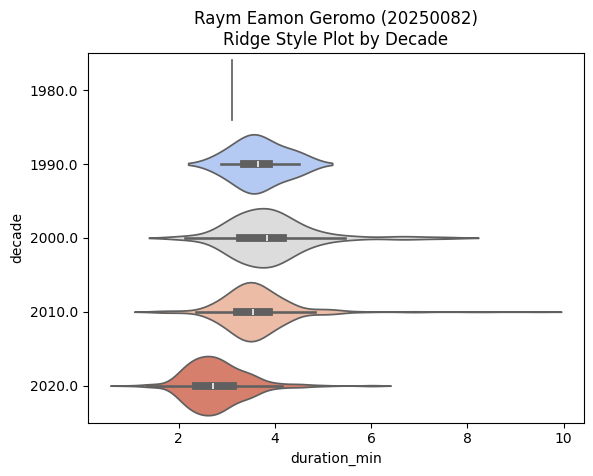

In [9]:
sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', orient='h')
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.show()

## 5. 

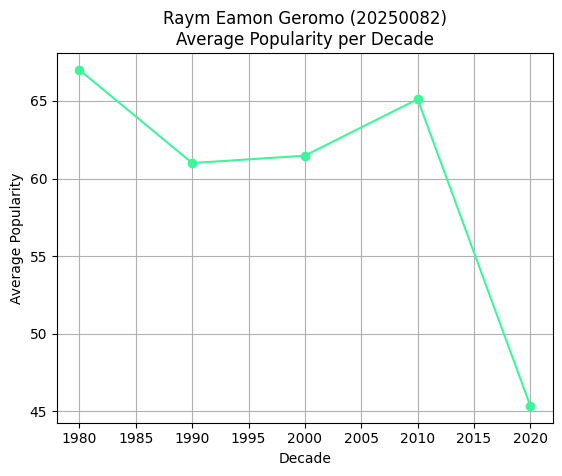

In [10]:
avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color=color1, marker='o')
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()

## 6.

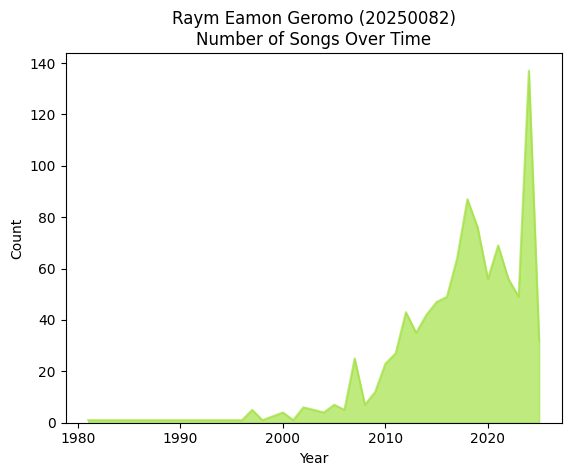

In [11]:
count_by_year = df['release_year'].value_counts().sort_index()
count_by_year.plot(kind='area', color=color2, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time")
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

## 7. 

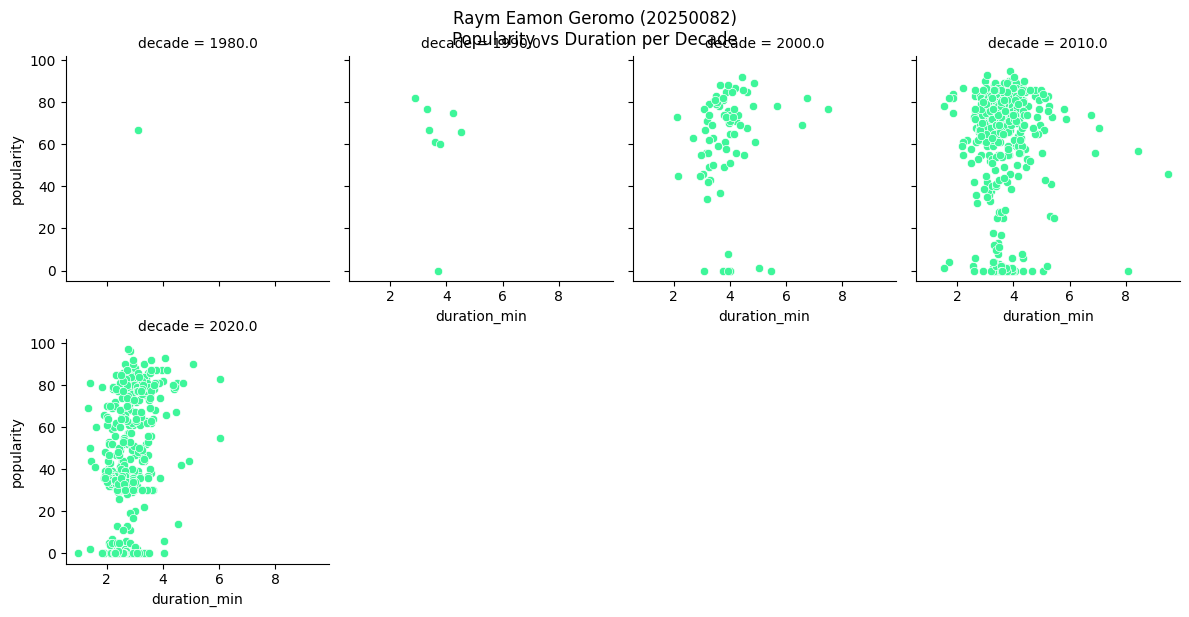

In [12]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', color=color1)
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02)
plt.show()

## 8. 

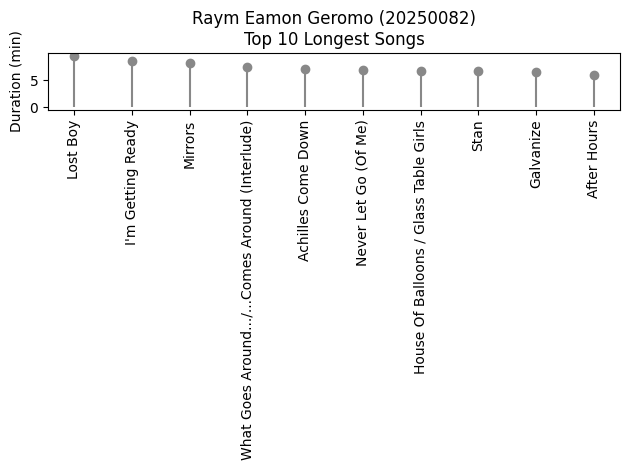

In [13]:
longest = df.nlargest(10, 'duration_min')
plt.stem(longest['track_name'], longest['duration_min'], linefmt='#888888', markerfmt='o', basefmt=" ")
plt.xticks(rotation=90)
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")
plt.ylabel('Duration (min)')
plt.tight_layout()
plt.show()

## 9.

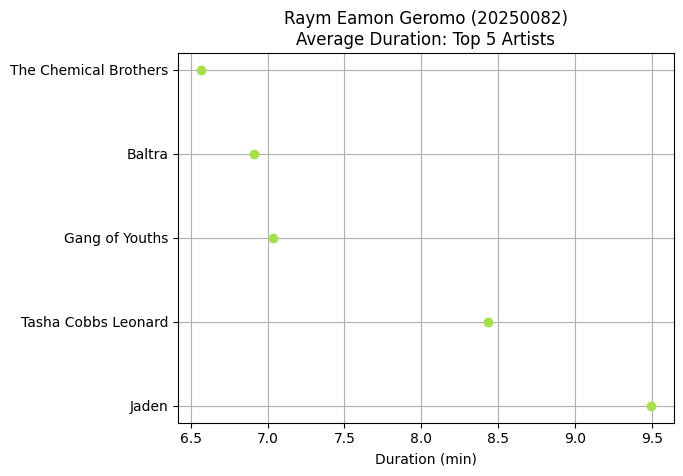

In [14]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2)
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists")
plt.xlabel('Duration (min)')
plt.grid(True)
plt.show()

## 10. 

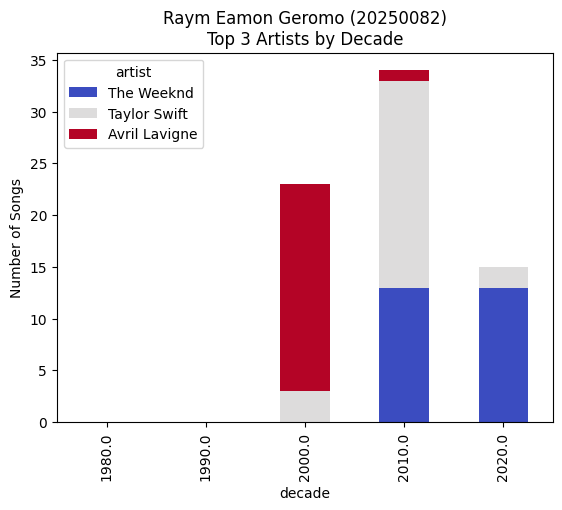

In [15]:
top3 = df['artist'].value_counts().head(3).index
crosstab = pd.crosstab(df['decade'], df['artist'])
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.show()

## 11. 

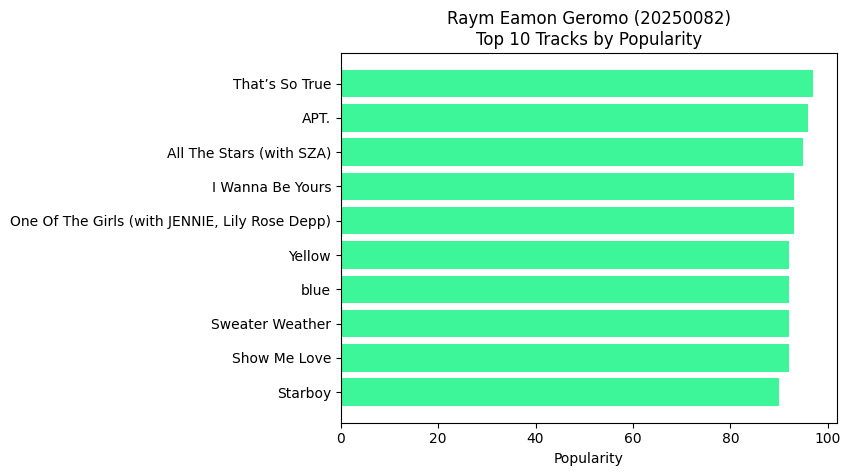

In [16]:
top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()

## 12. 

C:\Users\farah\AppData\Local\Temp\ipykernel_25552\3577873258.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=[color1, color2, '#888888'])


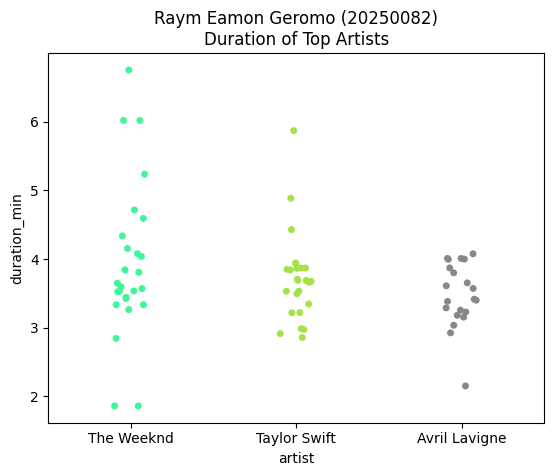

In [17]:
top_artists = df['artist'].value_counts().head(3).index
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=[color1, color2, '#888888'])
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists")
plt.show()

## 13. 

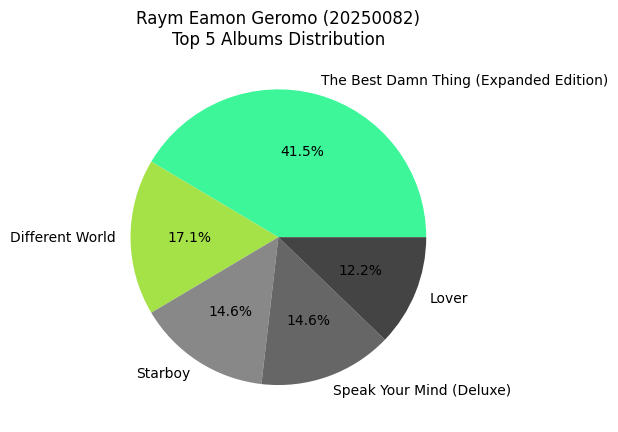

In [18]:
top_albums = df['album'].value_counts().head(5)
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=[color1, color2, '#888888', '#666666', '#444444'])
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution")
plt.show()

## 14. 

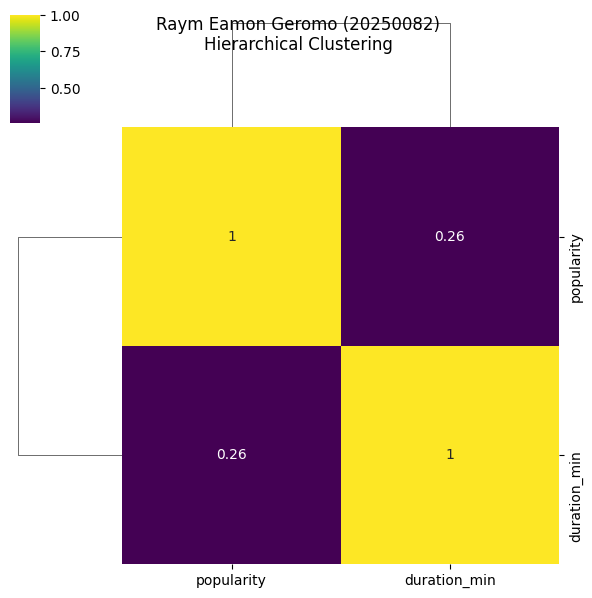

In [19]:
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', figsize=(6, 6))
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering")
plt.show()

## 15. 

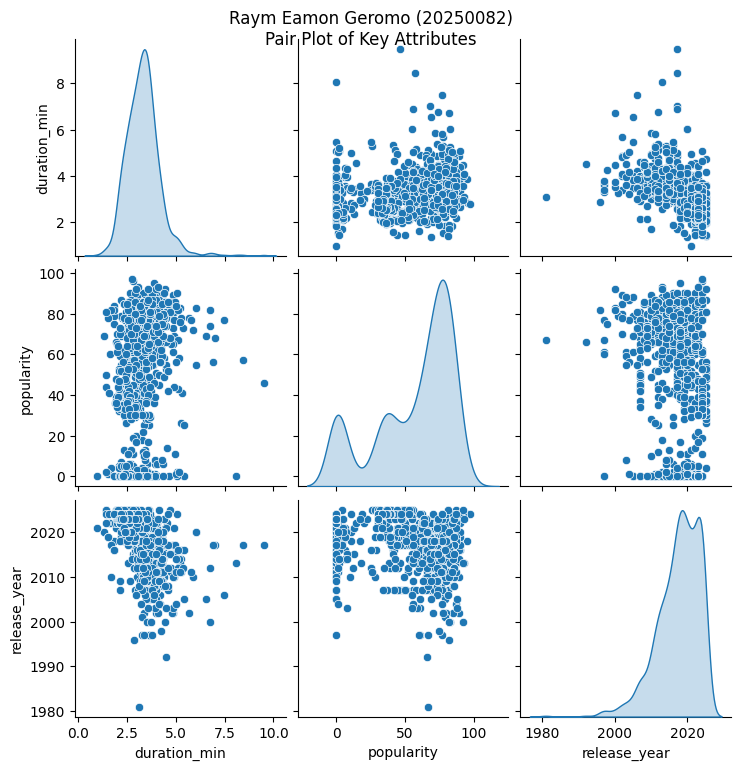

In [20]:
sns.pairplot(df[['duration_min', 'popularity', 'release_year']], diag_kind='kde')
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02)
plt.show()

## 16. 

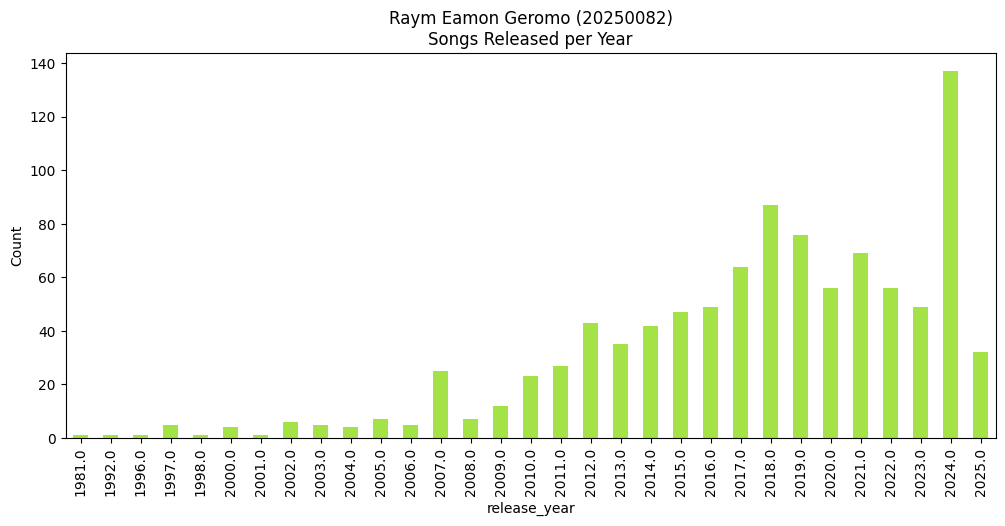

In [21]:
df['release_year'].value_counts().sort_index().plot(kind='bar', color=color2, figsize=(12,5))
plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')
plt.show()

## 17. 

C:\Users\farah\AppData\Local\Temp\ipykernel_25552\726865182.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


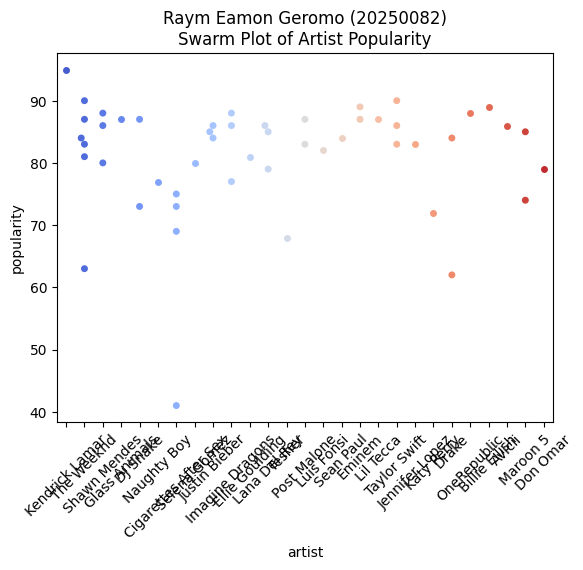

In [22]:
sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity")
plt.xticks(rotation=45)
plt.show()

## 18. 

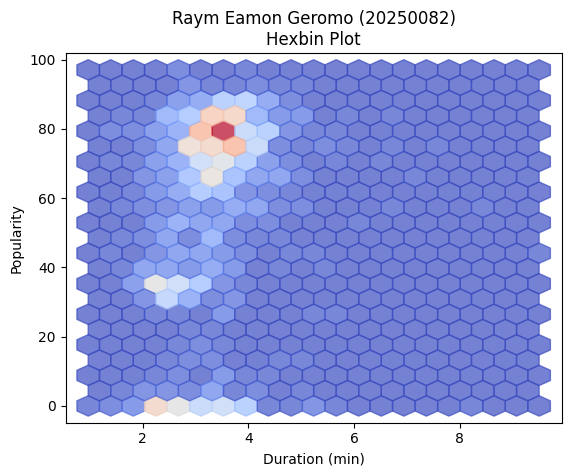

In [23]:
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, cmap='coolwarm', alpha=0.7)
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot")
plt.show()

## 19. 

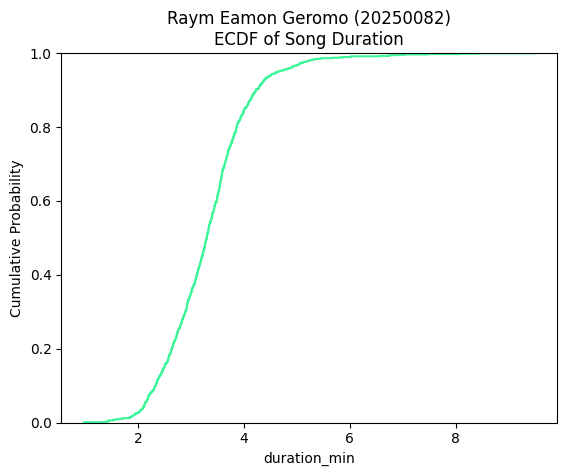

In [24]:
sns.ecdfplot(data=df, x='duration_min', color=color1)
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.ylabel('Cumulative Probability')
plt.show()

## 20. 

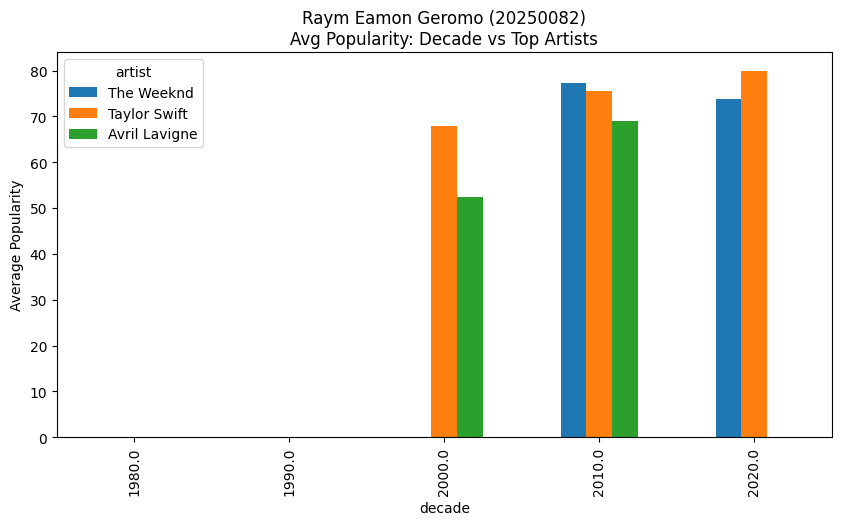

In [25]:
avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)
avg_artist_decade[top3].plot(kind='bar', figsize=(10, 5))
plt.title(f"{student_name} ({student_id})\nAvg Popularity: Decade vs Top Artists")
plt.ylabel('Average Popularity')
plt.show()